In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
#Loads the data
df = pd.read_csv('players_21.csv')

#Defining the Target
y = df['overall']

#Defining the features
X = df.drop(['overall', 'sofifa_id', 'player_url', 'short_name', 'long_name', 'dob', 'club_name', 'real_face'], axis=1)

#Filtering to keep only the numbers and simple text
X = X.select_dtypes(include=['number', 'object'])

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Data Loaded Successfully!")

Feature shape: (18944, 98)
Target shape: (18944,)
Data Loaded Successfully!


In [3]:
#Spliting the data: 80% players for training, 20% for testing
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split completed")
print(f"Training set size: {X_train.shape[0]} players")
print(f"Validation set size: {X_valid.shape[0]} players")

Data split completed
Training set size: 15155 players
Validation set size: 3789 players


In [4]:
# Identifying Numeric and Categorical columns
# Numeric: Age, Potential, Pace, Shooting, etc.
# Categorical: Preferred Foot, Work Rate, etc.
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# 2. Create Transformers
# Numeric: Fill missing values with median, then scale the data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Fill missing with 'missing', then convert text to numbers (OneHot)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Combine them into a Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [5]:
# Define the Model (Random Forest)
# n_estimators=100 means we are building 100 decision trees
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Create the full pipeline: Preprocessor -> Model
my_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', model)])

print("Model pipeline created successfully!")

Model pipeline created successfully!


In [6]:
# Train the model
print("Training the model... (This might take a moment)")
my_pipeline.fit(X_train, y_train)

# Predict on the validation set
preds = my_pipeline.predict(X_valid)

# Evaluate using Mean Absolute Error (MAE)
score = mean_absolute_error(y_valid, preds)
print(f"Validation MAE: {score:.2f}")

Training the model... (This might take a moment)


c:\Users\efosa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['defending_marking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\efosa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['defending_marking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Validation MAE: 0.20


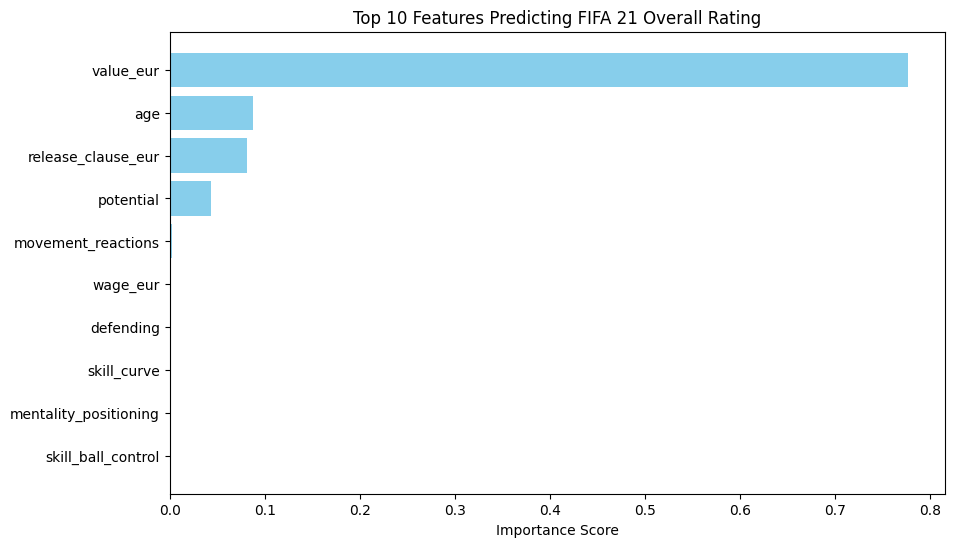

In [7]:
# Access the steps inside the pipeline
# 1. Get feature names from the preprocessor
preprocessor_step = my_pipeline.named_steps['preprocessor']
feature_names = preprocessor_step.get_feature_names_out()

# 2. Get importance scores from the model
model_step = my_pipeline.named_steps['model']
importances = model_step.feature_importances_

# 3. Create a DataFrame to view them
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Clean up feature names (remove "num__" and "cat__" prefixes for better readability)
importance_df['feature'] = importance_df['feature'].str.replace('num__', '').str.replace('cat__', '')

# Sort by importance and take the top 10
top_features = importance_df.sort_values(by='importance', ascending=False).head(10)

# 4. Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'], color='skyblue')
plt.gca().invert_yaxis() # Put the most important at the top
plt.title('Top 10 Features Predicting FIFA 21 Overall Rating')
plt.xlabel('Importance Score')
plt.show()

Retraining model on Attributes only


c:\Users\efosa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['defending_marking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\efosa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['defending_marking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


New Validation MAE: 0.85


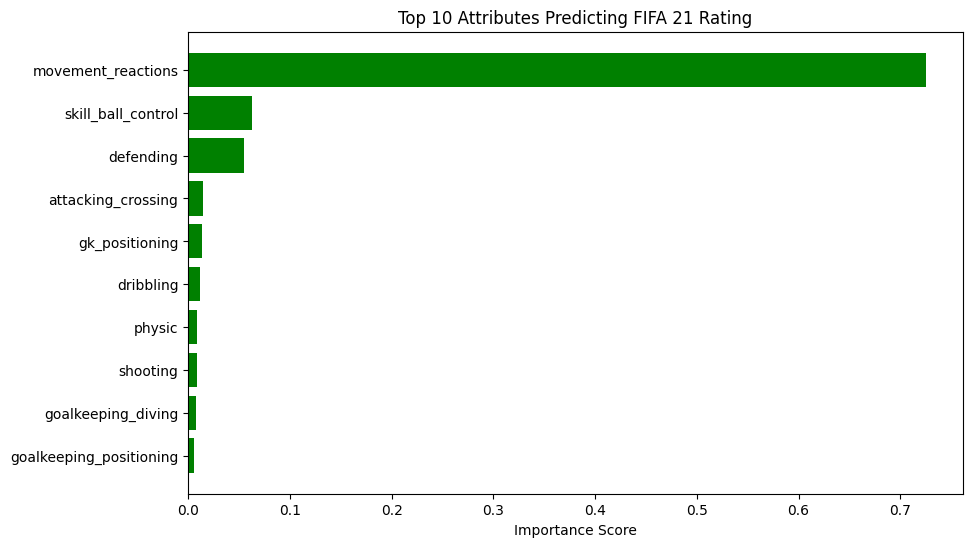

In [10]:
# 1. Reload the data to be fresh
df = pd.read_csv('players_21.csv')

# 2. Define Target
y = df['overall']

# 3. Define Features (removing "Money" and "Potential" columns)
X = df.drop(['overall', 'potential', 'value_eur', 'wage_eur', 'release_clause_eur', 
             'sofifa_id', 'player_url', 'short_name', 'long_name', 
             'dob', 'club_name', 'league_name', 'nationality', 'real_face'], axis=1)

# Keep only numeric/text columns
X = X.select_dtypes(include=['number', 'object'])

# 4. Split Data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================================================================
# ==============================================================================

# Identify the NEW list of columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Create Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine them into a Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Define the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Create the full pipeline
my_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', model)])

# ==============================================================================

# 5. Train on Attributes only
print("Retraining model on Attributes only")
my_pipeline.fit(X_train, y_train)

# 6. Evaluate
preds = my_pipeline.predict(X_valid)
score = mean_absolute_error(y_valid, preds)
print(f"New Validation MAE: {score:.2f}")

# 7. Plot the new Feature Importance
preprocessor_step = my_pipeline.named_steps['preprocessor']
feature_names = preprocessor_step.get_feature_names_out()
model_step = my_pipeline.named_steps['model']
importances = model_step.feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
# Clean up names
importance_df['feature'] = importance_df['feature'].str.replace('num__', '').str.replace('cat__', '')
top_features = importance_df.sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'], color='green')
plt.gca().invert_yaxis()
plt.title('Top 10 Attributes Predicting FIFA 21 Rating')
plt.xlabel('Importance Score')
plt.show()